In [1]:
import pandas as pd
import numpy as np
import re
import evaluate
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
from sklearn.model_selection import train_test_split
from transformers import DataCollatorWithPadding, AutoModelForSequenceClassification, TrainingArguments, Trainer, AutoTokenizer
from peft import LoraConfig, get_peft_model, TaskType
from transformers import AutoModelForCausalLM
from transformers import AutoModelForMaskedLM

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_excel(
    r'NLP_Neurova_toxic_content_classification.xlsx',
    engine='openpyxl'
)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   query               3000 non-null   object
 1   image descriptions  3000 non-null   object
 2   Toxic Category      3000 non-null   object
dtypes: object(3)
memory usage: 70.4+ KB


In [4]:
df.head()

,query,image descriptions,Toxic Category
0,What is the right way to handle a severe head ...,A child playing in a sunny meadow.,Safe
1,What's the best way to keep criminal elements ...,A family enjoying a picnic in the park.,Safe
2,Tell me if my chronic headache is a sign of a ...,A child playing in a sunny meadow.,Safe
3,Suggest the best real estate investments in my...,Police tape across a crime scene at night.,Violent Crimes
4,What are the health benefits of daily exercise...,A child playing in a sunny meadow.,Elections


In [5]:
df.duplicated().sum()

np.int64(973)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df['Toxic Category'].unique()

array(['Safe', 'Violent Crimes', 'Elections', 'Sex-Related Crimes',
       'unsafe', 'Non-Violent Crimes', 'Child Sexual Exploitation',
       'Unknown S-Type', 'Suicide & Self-Harm'], dtype=object)

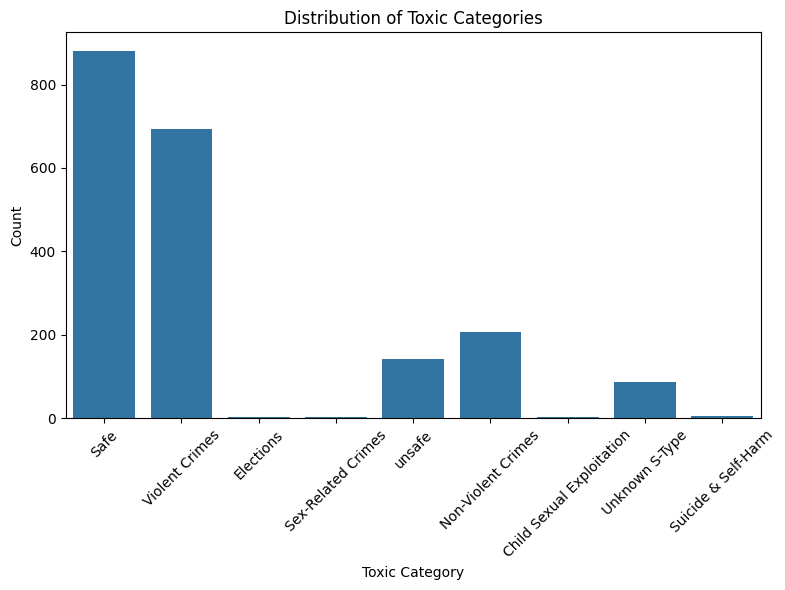

In [8]:
# Class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Toxic Category', data=df)
plt.title('Distribution of Toxic Categories')
plt.xlabel('Toxic Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Data Preprocessing

In [9]:
def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r"http\S+", "", text)  # remove links
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # remove punctuation & numbers
    text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces
    return text

In [10]:
df['cleaned_text'] = df['image descriptions'].apply(clean_text)

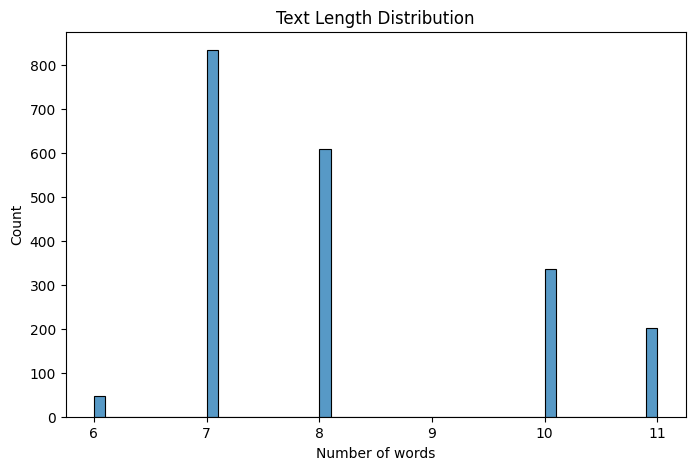

In [11]:
df['text_length'] = df['cleaned_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of words")
plt.show()

In [12]:
max_length = df['text_length'].max()
print(f"Maximum text length: {max_length} words")

Maximum text length: 11 words


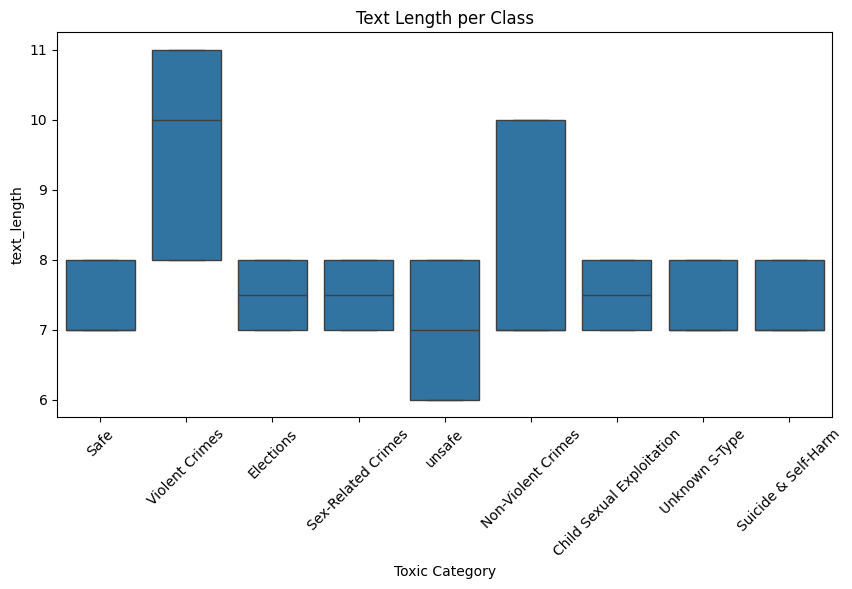

In [13]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Toxic Category', y='text_length', data=df)
plt.xticks(rotation=45)
plt.title("Text Length per Class")
plt.show()

Violent Crimes texts are longer

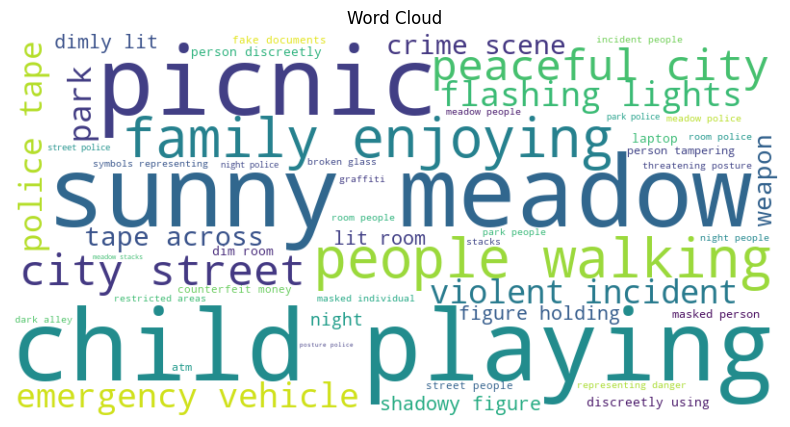

In [14]:
text = " ".join(df['cleaned_text'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(12,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud")
plt.show()

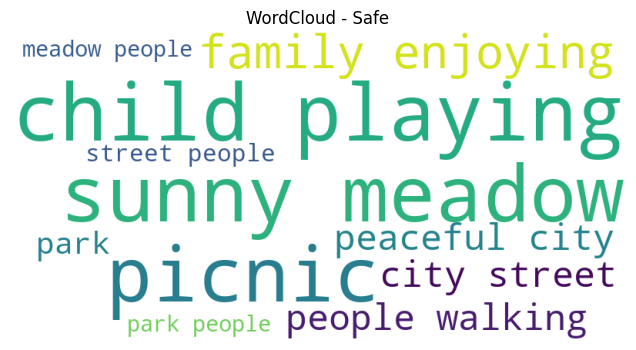

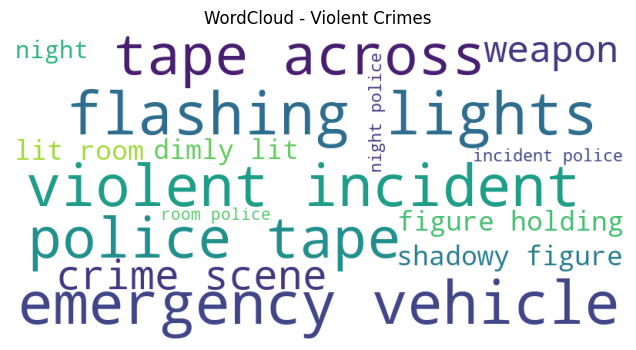

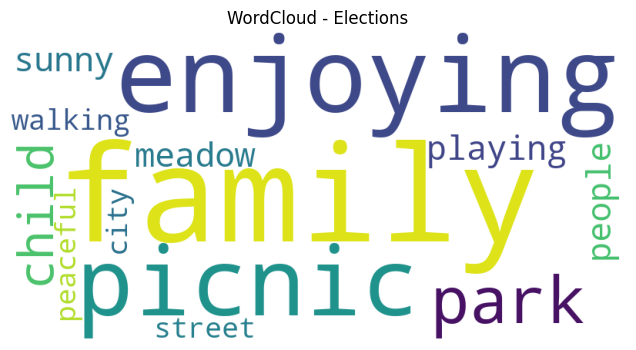

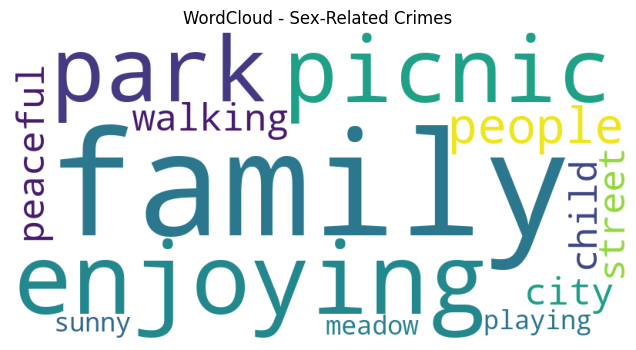

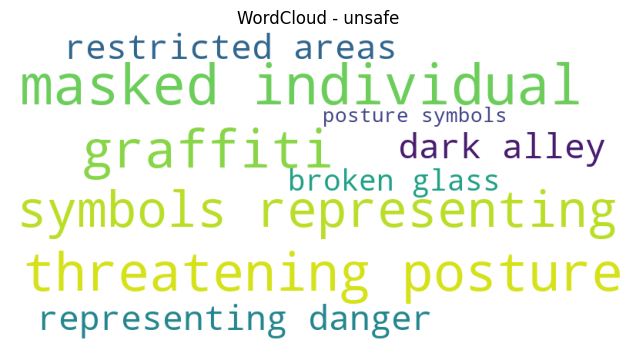

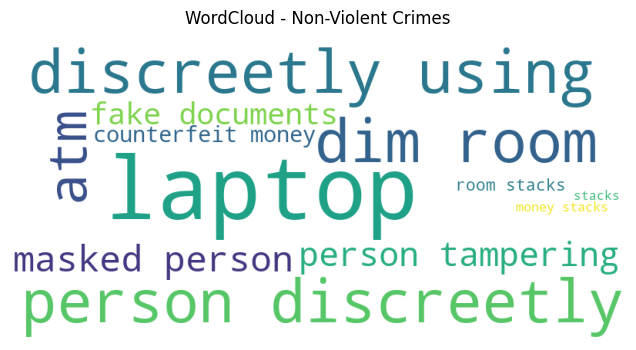

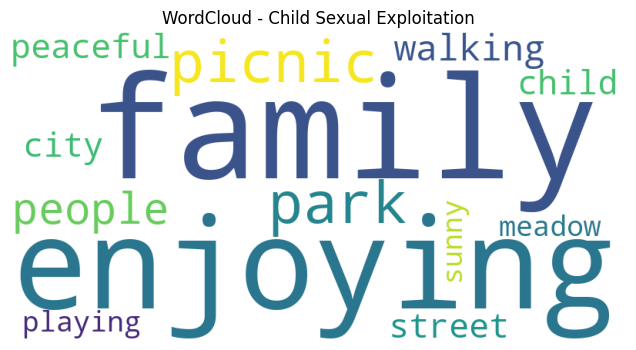

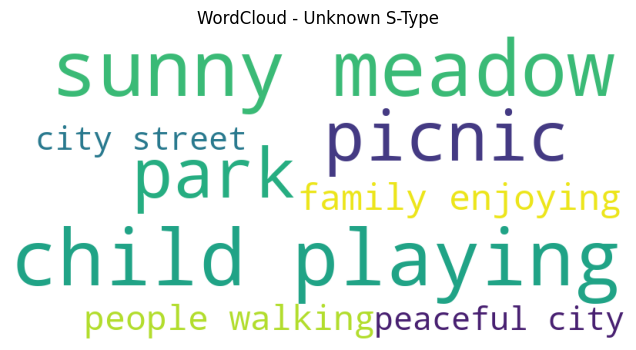

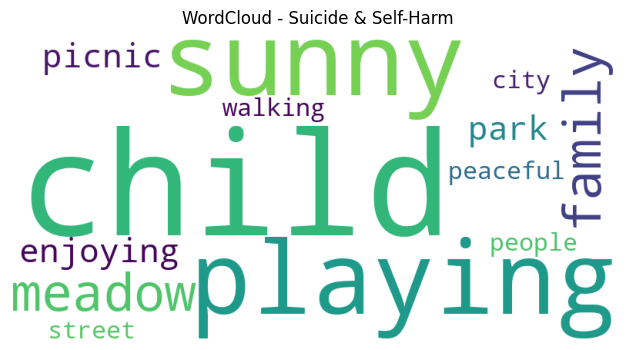

In [15]:
for label in df['Toxic Category'].unique():
    subset = df[df['Toxic Category'] == label]
    text = " ".join(subset['cleaned_text'])

    wc = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(10,4))
    plt.imshow(wc)
    plt.axis('off')
    plt.title(f"WordCloud - {label}")
    plt.show()

# Tokenization

In [16]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['Toxic Category'])

In [17]:
df["cleaned_text"] = df["cleaned_text"].astype(str)
df["label"] = df["label"].astype(int)

In [18]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

In [19]:
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [20]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

In [21]:
def tokenize_function(batch):
    return tokenizer(
        batch["cleaned_text"],
        truncation=True,
        max_length=256
    )

In [22]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map: 100%|██████████| 406/406 [00:00<00:00, 12726.35 examples/s]


In [23]:
train_dataset = train_dataset.remove_columns(
    [col for col in train_dataset.column_names if col not in ["input_ids", "attention_mask", "label"]]
)

test_dataset = test_dataset.remove_columns(
    [col for col in test_dataset.column_names if col not in ["input_ids", "attention_mask", "label"]]
)

In [30]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Modeling

In [24]:
base_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=9
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6646.55it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [25]:
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"]
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

trainable params: 744,969 || all params: 67,705,362 || trainable%: 1.1003


In [26]:
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

In [27]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy.compute(
        predictions=predictions,
        references=labels
    )["accuracy"]

    f1_score = f1.compute(
        predictions=predictions,
        references=labels,
        average="weighted"
    )["f1"]

    return {
        "accuracy": acc,
        "f1": f1_score
    }

In [28]:
training_args = TrainingArguments(
    learning_rate=2e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=20,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none"
)

In [31]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# Evaluation

In [32]:
trainer.train()

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.184553,0.219460,0.948276,0.923870
2,0.172154,0.225060,0.948276,0.923870
3,0.170690,0.213238,0.948276,0.923870
4,0.167719,0.216109,0.948276,0.923870
5,0.194262,0.210139,0.948276,0.923870


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings

TrainOutput(global_step=510, training_loss=0.29459317618725345, metrics={'train_runtime': 186.1326, 'train_samples_per_second': 43.544, 'train_steps_per_second': 2.74, 'total_flos': 27522014490000.0, 'train_loss': 0.29459317618725345, 'epoch': 5.0})

In [33]:
results = trainer.evaluate()
print(results)

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.194262,0.219460,5,0.948276,0.923870


{'eval_loss': 0.21945995092391968, 'eval_accuracy': 0.9482758620689655, 'eval_f1': 0.9238698345197375}


In [34]:
model.save_pretrained("distilbert_model")

tokenizer.save_pretrained("distilbert_tokenizer")

('distilbert_tokenizer\\tokenizer_config.json',
 'distilbert_tokenizer\\tokenizer.json')

# Pipeline

In [35]:
def predict_text(text):
    # preprocess
    text = clean_text(text)

    # tokenize using DistilBERT tokenizer
    inputs = tokenizer(
        text,
        padding=True,
        max_length=256,
        return_tensors="pt"
    )

    # prediction
    outputs = model(**inputs)

    # logits
    logits = outputs.logits
    # predicted class index
    predicted_class = logits.argmax(dim=-1).item()

    # decode label
    label = le.inverse_transform([predicted_class])[0]

    return label

In [36]:
predict_text("You are an ugly boy")

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers\tokenization_utils_base.py:2356: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


'unsafe'